In [1]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from mppi import Utilities as U, Parsers as P
from mppi.Utilities import FourierTransform as F
import matplotlib.pyplot as plt
import numpy as np
import os

# Analysis of the Fourier Transform

We describe the usage the np.fft module to deal with the FT of real-valued time dependent array.
In this case we can use the rfft functions that represent only the positive part of the frequency spectra.

The common shape of the array is (component,time).

For istance we can use the real-time polarization

In [3]:
file = 'YamboParser_test/nl_results/LiF_lr/ndb.Nonlinear'
data = P.YamboNLDBParser(file)

Parse file : YamboParser_test/nl_results/LiF_lr/ndb.Nonlinear
Field 2 not found
Field 3 not found


In [4]:
time = data.get_time()
P_t = data.Polarization[0]
time.size,P_t.shape

(2001, (3, 2001))

We denote with $N_t$ and $dt$ the number of samplings and time step of the t variable.
According to the np.fft module the frequency variable is defined within the range
$$
f = [0, 1, ...,     N_t/2-1,     N_t/2] / (dtN_t)    
$$
if Nt is even, so that $_Nf = Nt/2+1$. Instead if $N_t$ is odd we have 
$$
f = [0, 1, ..., (N_t-1)/2-1, (N_t-1)/2] / (dtN_t)   , 
$$
so that $N_f = (N_t+1)/2$.

The maximum value of the frequency is given by
$$
f_{max} = 1/(2dt) \,\, , \quad N_t \,\, even
$$
and 
$$
f_{max} = (N_t-1)/(2N_tdt) \,\, , \quad N_t \,\, odd
$$
and the frequency step is $1/(N_tdt)$.

We make usage of the rfftfreq function to build the frequency sampling

In [5]:
Nt = time.size
dt = time[1]-time[0]
freqs = np.fft.rfftfreq(Nt,d=dt)
Nt,freqs.size,freqs[-1],freqs[1]-freqs[0]

(2001, 1001, np.float64(9.995002417381007), np.float64(0.009995002417381008))

The FT can be computed easily for the whole array

In [6]:
P_w = np.fft.rfft(P_t)
P_w.shape

(3, 1001)

an optional variable n can be used to set the number of points along transformation axis in the input.
If n is smaller than the length of the input, the input is cropped. If it is larger, the input is padded with zeros.

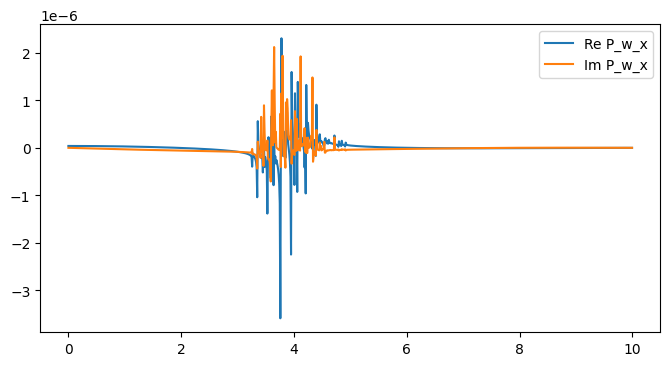

In [7]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(freqs,np.real(P_w[0]),label='Re P_w_x')
ax1.plot(freqs,np.imag(P_w[0]),label='Im P_w_x')
ax1.legend()

We can transform back in the time domain using the irfft function

In [8]:
Ift_t = np.fft.irfft(P_w,n=time.size)
Ift_t.shape

(3, 2001)

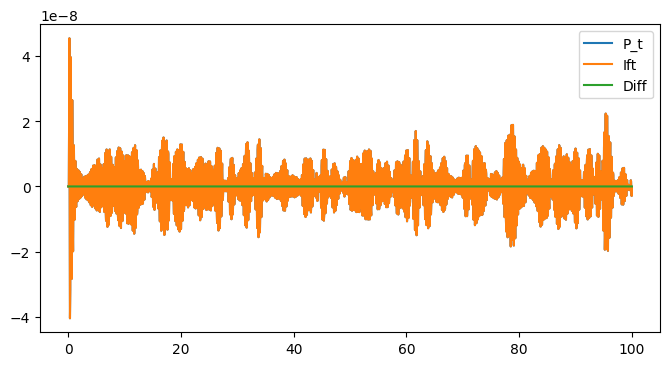

In [9]:
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(time,P_t[0],label='P_t')
ax1.plot(time,Ift_t[0],label='Ift')
ax1.plot(time,P_t[0]-Ift_t[0],label='Diff')
ax1.legend()

The module contains a simple function to determine the number of points in the time domain and the time step
in order to have the wanted frequency range

In [10]:
F.set_time_sampling_pars(27,0.1)

Time step = 0.0765864388148148
Number of time points = 540


(0.0765864388148148, 540)

It is also possible to compute the energy array given the time sampling properties

In [13]:
energy = F.eval_energy_array(1000,dt=0.1)
energy[0:10]

Maximum energy value = 20.678338479999997
Energy sampling step = 0.04135667696


array([0.        , 0.04135668, 0.08271335, 0.12407003, 0.16542671,
       0.20678338, 0.24814006, 0.28949674, 0.33085342, 0.37221009])